# Omi Card Game - Neural Network Predictor
This notebook covers the preprocessing of the Omi dataset for model training.

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import ast

# Machine Learning libraries
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

## 1. Load the Dataset

In [37]:
DATASET_PATH = 'omi_dataset.csv'

if os.path.exists(DATASET_PATH):
    df = pd.read_csv(DATASET_PATH)
    print(f"Successfully loaded dataset with {len(df)} records.")
else:
    print(f"Dataset not found at {DATASET_PATH}.")

Successfully loaded dataset with 10000 records.


## 2. Parse Strings into Python Lists

In [38]:
columns_to_parse = ["p0_start", "p1_start", "p2_start", "p3_start", "history"]

for col in columns_to_parse:
    df[col] = df[col].apply(ast.literal_eval)

print("Parsing complete.")

Parsing complete.


## 3. Card Encoding Logic

In [39]:
RANKS = ["6", "7", "8", "9", "10", "J", "Q", "K", "A"]
SUITS = ["Clubs", "Diamonds", "Hearts", "Spades"]
ALL_CARDS = [f"{r}_{s}" for r in RANKS for s in SUITS]

card_to_idx = {card: i for i, card in enumerate(ALL_CARDS)}
idx_to_card = {i: card for card, i in card_to_idx.items()}

def encode_hand(hand):
    vec = [0] * 36
    for card in hand:
        if card in card_to_idx:
            vec[card_to_idx[card]] = 1
    return vec

## 4. Step 3 — Write parser function

In [40]:
def parse_trick(trick_text):
    # Example input: "Trick 1: P0 played Q_Diamonds, P1 played K_Diamonds, ... Winner: P2"
    
    # Step 1: remove "Trick X: "
    parts = trick_text.split(": ")[1]
    
    # Step 2: remove " Winner: P2"
    parts = parts.split(". Winner")[0]
    
    # Step 3: split into individual plays
    plays = parts.split(", ")
    
    result = []
    for play in plays:
        tokens = play.split(" ")
        player = tokens[0]         # P0
        card = tokens[2]           # Q_Diamonds
        result.append((player, card))
    
    return result

# Test it
example_trick = df["history"][0][0]
print("Parsed example trick:", parse_trick(example_trick))

Parsed example trick: [('P0', 'Q_Diamonds'), ('P1', 'K_Diamonds'), ('P2', 'A_Diamonds'), ('P3', '9_Diamonds')]


## 5. Step 5 — Simulation Logic and Feature Building
We will now loop through the games and simulate them move-by-move to collect features.

In [41]:
X = [] # Features
y = [] # Labels (the card played)

print(f"Processing {len(df)} games...")

for i in range(len(df)):
    # Initialize current hands from the starting state columns
    player_hands = {
        'P0': list(df['p0_start'][i]),
        'P1': list(df['p1_start'][i]),
        'P2': list(df['p2_start'][i]),
        'P3': list(df['p3_start'][i])
    }
    
    trump = df['trump'][i]
    previous_cards = []
    
    # Loop through each trick in the history
    for trick_text in df['history'][i]:
        trick_plays = parse_trick(trick_text)
        table_cards = []
        
        for player_id, card_played in trick_plays:
            # 1. BUILD FEATURES for this specific move
            # Features = [Hand (36)] + [Table (36)] + [Played (36)] + [Trump One-Hot (4)] + [Player ID (4)] + ...
            hand_vec = encode_hand(player_hands[player_id])
            table_vec = encode_hand(table_cards)
            prev_vec = encode_hand(previous_cards)
            
            # Trump encoding (C, D, H, S)
            trump_vec = [0, 0, 0, 0]
            trump_vec[SUITS.index(trump)] = 1
            
            # Combine all features
            features = hand_vec + table_vec + prev_vec + trump_vec
            
            X.append(features)
            y.append(card_to_idx[card_played])
            
            # 2. UPDATE STATE for next move
            player_hands[player_id].remove(card_played)
            table_cards.append(card_played)
            previous_cards.append(card_played)

X = np.array(X)
y = np.array(y)

print(f"Created {len(X)} training samples.")
print(f"Feature vector size: {len(X[0])}")

Processing 10000 games...
Created 360000 training samples.
Feature vector size: 112


In [42]:
print(X[0])
print(y[0])

[1 0 1 0 0 1 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0]
25


In [43]:
def encode_cards(cards):
    vec = [0] * 36
    for card in cards:
        vec[card_to_idx[card]] = 1
    return vec

In [44]:
X = []
y = []

for i, row in df.iterrows():
    
    hands = {
        "P0": row["p0_start"].copy(),
        "P1": row["p1_start"].copy(),
        "P2": row["p2_start"].copy(),
        "P3": row["p3_start"].copy(),
    }
    
    previous_cards = []
    
    for trick in row["history"]:
        
        table_cards = []
        plays = parse_trick(trick)
        
        for player, card in plays:
            
            # 🔵 Build features
            hand_vec = encode_cards(hands[player])
            table_vec = encode_cards(table_cards)
            prev_vec = encode_cards(previous_cards)
            
            # 🔥 Combine
            full_vec = hand_vec + table_vec + prev_vec
            
            # OUTPUT
            label = card_to_idx[card]
            
            X.append(full_vec)
            y.append(label)
            
            # 🔴 Update state
            hands[player].remove(card)
            table_cards.append(card)
            previous_cards.append(card)

In [45]:
print(len(X[0]))

108


In [46]:
def encode_trump(trump):
    suits = ["Clubs", "Diamonds", "Hearts", "Spades"]
    return [1 if s == trump else 0 for s in suits]

In [47]:
def encode_lead_suit(table_cards):
    suits = ["Clubs", "Diamonds", "Hearts", "Spades"]
    
    if len(table_cards) == 0:
        return [0,0,0,0,1]  # NoLead
    
    suit = table_cards[0].split("_")[1]
    return [1 if s == suit else 0 for s in suits] + [0]

In [48]:
def encode_position(pos):
    vec = [0,0,0,0]
    vec[pos] = 1
    return vec

In [49]:
def encode_trick(trick_index):
    return [trick_index / 8]

In [50]:
def encode_team_flag():
    return [0]

In [51]:
X = []
y = []

for i, row in df.iterrows():
    
    hands = {
        "P0": row["p0_start"].copy(),
        "P1": row["p1_start"].copy(),
        "P2": row["p2_start"].copy(),
        "P3": row["p3_start"].copy(),
    }
    
    previous_cards = []
    trump_vec = encode_trump(row["trump"])
    
    for trick_index, trick in enumerate(row["history"]):
        
        table_cards = []
        plays = parse_trick(trick)
        
        for pos, (player, card) in enumerate(plays):
            
            # 🔵 Core features
            hand_vec = encode_cards(hands[player])
            table_vec = encode_cards(table_cards)
            prev_vec = encode_cards(previous_cards)
            
            # 🔵 New features
            lead_vec = encode_lead_suit(table_cards)
            pos_vec = encode_position(pos)
            trick_vec = encode_trick(trick_index)
            team_flag = encode_team_flag()
            
            # 🔥 Combine ALL
            full_vec = (
                hand_vec +
                table_vec +
                prev_vec +
                trump_vec +
                lead_vec +
                trick_vec +
                pos_vec +
                team_flag
            )
            
            # OUTPUT
            label = card_to_idx[card]
            
            X.append(full_vec)
            y.append(label)
            
            # 🔴 Update state
            hands[player].remove(card)
            table_cards.append(card)
            previous_cards.append(card)

In [52]:
print(len(X[0]))

123


In [53]:
import numpy as np

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(360000, 123)
(360000,)


In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [55]:
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(123,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(36, activation='softmax')
])

e:\Omi-predictor\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [56]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [57]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/5
8100/8100 ━━━━━━━━━━━━━━━━━━━━ 9s 955us/step - accuracy: 0.7925 - loss: 0.6216 - val_accuracy: 0.8542 - val_loss: 0.4062
Epoch 2/5
8100/8100 ━━━━━━━━━━━━━━━━━━━━ 8s 926us/step - accuracy: 0.8798 - loss: 0.3389 - val_accuracy: 0.8889 - val_loss: 0.3170
Epoch 3/5
8100/8100 ━━━━━━━━━━━━━━━━━━━━ 10s 918us/step - accuracy: 0.8954 - loss: 0.2969 - val_accuracy: 0.8935 - val_loss: 0.3049
Epoch 4/5
8100/8100 ━━━━━━━━━━━━━━━━━━━━ 7s 914us/step - accuracy: 0.9034 - loss: 0.2721 - val_accuracy: 0.8927 - val_loss: 0.3161
Epoch 5/5
8100/8100 ━━━━━━━━━━━━━━━━━━━━ 8s 955us/step - accuracy: 0.9091 - loss: 0.2544 - val_accuracy: 0.9026 - val_loss: 0.2792


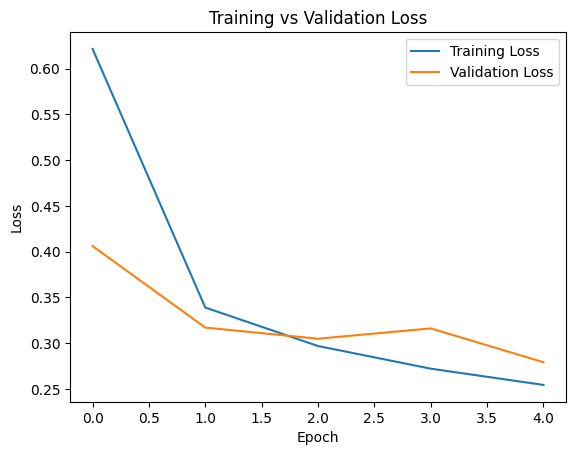

In [59]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')

plt.legend()
plt.show()

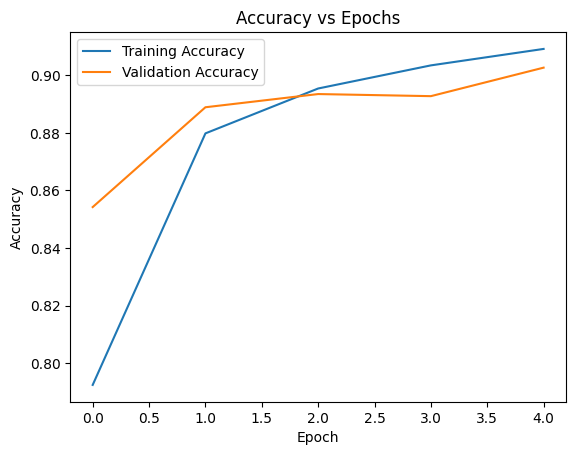

In [60]:
plt.figure()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')

plt.legend()
plt.show()

In [61]:
import numpy as np

sample = X_test[0:1]

pred = model.predict(sample)

print("Predicted probabilities:", pred)
print("Chosen card index:", np.argmax(pred))
print("Actual card index:", y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
Predicted probabilities: [[1.9010697e-06 6.3999073e-07 1.2438258e-04 3.7137888e-04 9.8365456e-01
  1.7259606e-06 2.2675538e-04 7.2410978e-05 8.5009178e-03 1.4284153e-07
  5.7454163e-04 7.3551208e-05 8.7413389e-11 1.8933837e-06 7.0441120e-06
  5.4894739e-05 4.5033324e-10 2.6444141e-07 1.3685451e-04 2.7709058e-04
  2.3301788e-10 3.2026449e-07 2.2592433e-04 1.9492461e-05 3.0078797e-11
  6.3245604e-09 8.8454770e-05 3.7157547e-06 6.2591665e-10 8.1056228e-09
  5.5717835e-03 7.9107165e-09 1.0835424e-07 1.1689381e-09 8.3724162e-06
  9.0233783e-07]]
Chosen card index: 4
Actual card index: 4


2250/2250 ━━━━━━━━━━━━━━━━━━━━ 1s 531us/step


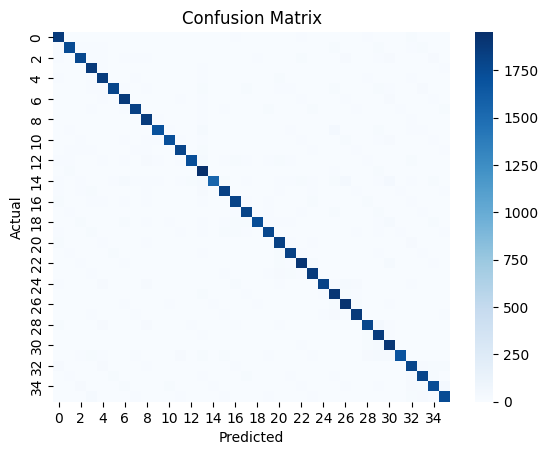

In [62]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

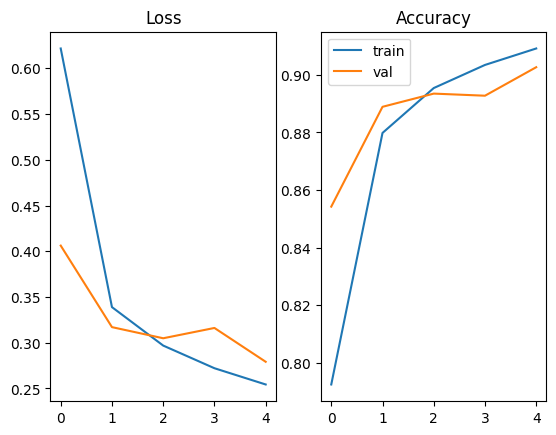

In [63]:
plt.figure()

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')

plt.legend()
plt.show()

In [58]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

2250/2250 ━━━━━━━━━━━━━━━━━━━━ 2s 747us/step - accuracy: 0.9038 - loss: 0.2739
Test Accuracy: 0.9038194417953491


In [64]:
def count_valid_moves(hand, lead_suit):
    if not lead_suit:
        return len(hand)
    
    same_suit = [c for c in hand if c.split("_")[1] == lead_suit]
    
    return len(same_suit) if same_suit else len(hand)

In [ ]:
print(count_valid_moves)

In [65]:
pred = model.predict(X_test)

top3 = np.argsort(pred, axis=1)[:, -3:]

correct = sum([y_test[i] in top3[i] for i in range(len(y_test))])

print("Top-3 Accuracy:", correct / len(y_test))

2250/2250 ━━━━━━━━━━━━━━━━━━━━ 1s 566us/step
Top-3 Accuracy: 0.9962361111111111
